# Home Credit Score Card Model
Proyek ini bertujuan memprediksi apakah pemohon pinjaman akan mengalami kesulitan pembayaran (default).
- **TARGET = 0**: Tidak ada kesulitan pembayaran
- **TARGET = 1**: Ada kesulitan pembayaran

---
## 1. IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

print('Semua library berhasil diimport.')

Semua library berhasil diimport.


---
## 2. LOAD DATA

In [2]:
df_train = pd.read_csv('/kaggle/input/datasets/baboll/rakamin/application_train.csv')
df_test  = pd.read_csv('/kaggle/input/datasets/baboll/rakamin/application_test.csv')

print(f'Shape train : {df_train.shape}')
print(f'Shape test  : {df_test.shape}')

Shape train : (307511, 122)
Shape test  : (48744, 121)


---
## 3. EXPLORATORY DATA ANALYSIS (EDA)

### 3.1 Tampilan Awal Data

In [3]:
print('=== HEAD DATA TRAIN ===')
display(df_train.head())

print('\n=== HEAD DATA TEST ===')
display(df_test.head())

=== HEAD DATA TRAIN ===


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0



=== HEAD DATA TEST ===


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Info & Tipe Data

In [4]:
print('=== INFO DATA TRAIN ===')
df_train.info(verbose=True, memory_usage='deep')

print('\n=== INFO DATA TEST ===')
df_test.info(verbose=True, memory_usage='deep')

=== INFO DATA TRAIN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH            

### 3.3 Jumlah Nilai Unik Tiap Kolom

In [5]:
print('=== UNIQUE VALUES - TRAIN ===')
print(df_train.nunique().to_string())

print('\n=== UNIQUE VALUES - TEST ===')
print(df_test.nunique().to_string())

=== UNIQUE VALUES - TRAIN ===
SK_ID_CURR                      307511
TARGET                               2
NAME_CONTRACT_TYPE                   2
CODE_GENDER                          3
FLAG_OWN_CAR                         2
FLAG_OWN_REALTY                      2
CNT_CHILDREN                        15
AMT_INCOME_TOTAL                  2548
AMT_CREDIT                        5603
AMT_ANNUITY                      13672
AMT_GOODS_PRICE                   1002
NAME_TYPE_SUITE                      7
NAME_INCOME_TYPE                     8
NAME_EDUCATION_TYPE                  5
NAME_FAMILY_STATUS                   6
NAME_HOUSING_TYPE                    6
REGION_POPULATION_RELATIVE          81
DAYS_BIRTH                       17460
DAYS_EMPLOYED                    12574
DAYS_REGISTRATION                15688
DAYS_ID_PUBLISH                   6168
OWN_CAR_AGE                         62
FLAG_MOBIL                           2
FLAG_EMP_PHONE                       2
FLAG_WORK_PHONE                   

### 3.4 Missing Values

In [6]:
print('=== MISSING VALUES - TRAIN ===')
display(df_train.isnull().sum())

print('\n=== MISSING VALUES - TEST ===')
display(df_test.isnull().sum())

=== MISSING VALUES - TRAIN ===


SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64


=== MISSING VALUES - TEST ===


SK_ID_CURR                       0
NAME_CONTRACT_TYPE               0
CODE_GENDER                      0
FLAG_OWN_CAR                     0
FLAG_OWN_REALTY                  0
                              ... 
AMT_REQ_CREDIT_BUREAU_DAY     6049
AMT_REQ_CREDIT_BUREAU_WEEK    6049
AMT_REQ_CREDIT_BUREAU_MON     6049
AMT_REQ_CREDIT_BUREAU_QRT     6049
AMT_REQ_CREDIT_BUREAU_YEAR    6049
Length: 121, dtype: int64

### 3.5 Pengecekan Duplikat

In [7]:
duplicates_train = df_train[df_train.duplicated()]
duplicates_test  = df_test[df_test.duplicated()]

print(f'Jumlah duplikat di data train : {len(duplicates_train)}')
print(f'Jumlah duplikat di data test  : {len(duplicates_test)}')

Jumlah duplikat di data train : 0
Jumlah duplikat di data test  : 0


### 3.6 Distribusi TARGET (Imbalanced Check)

Distribusi kelas TARGET:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Proporsi berisiko (TARGET=1): 8.07%


/tmp/ipykernel_55/389400483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=df_train, palette='Set2')


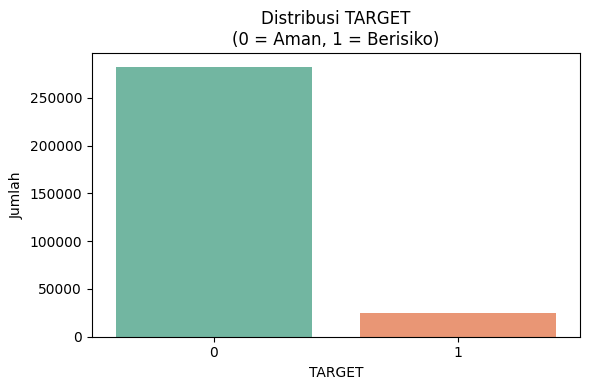

In [8]:
print('Distribusi kelas TARGET:')
print(df_train['TARGET'].value_counts())
print(f'Proporsi berisiko (TARGET=1): {df_train["TARGET"].mean():.2%}')

plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=df_train, palette='Set2')
plt.title('Distribusi TARGET\n(0 = Aman, 1 = Berisiko)')
plt.xlabel('TARGET')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

### 3.7 Distribusi TARGET Berdasarkan Jenis Kelamin

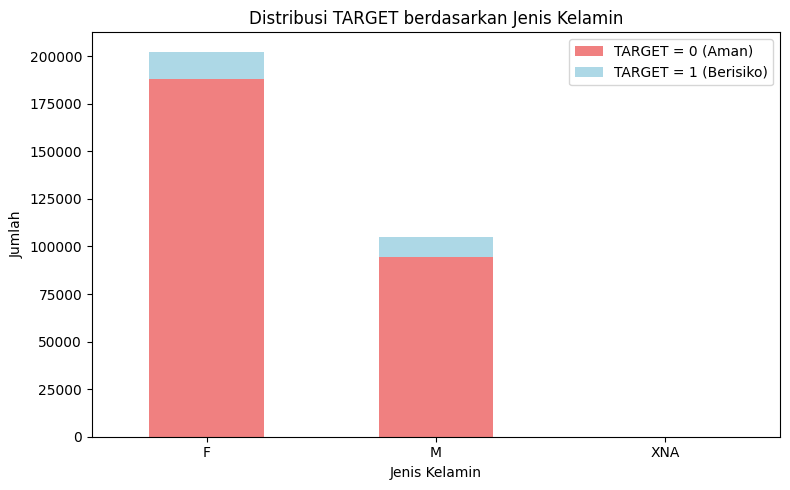

In [9]:
gender_target = df_train.groupby(['CODE_GENDER', 'TARGET']).size().unstack(fill_value=0)

gender_target.plot(kind='bar', stacked=True, figsize=(8, 5),
                   color=['lightcoral', 'lightblue'])
plt.title('Distribusi TARGET berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah')
plt.legend(['TARGET = 0 (Aman)', 'TARGET = 1 (Berisiko)'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Mengambil kolom yang hanya berisi angka saja dari data train
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_numeric = df_train.select_dtypes(include=numerics)

# Menghitung korelasi fitur numerik dengan TARGET
correlations = df_numeric.corr()['TARGET'].sort_values()

# Menampilkan 10 korelasi paling positif (paling berisiko gagal bayar)
print('Korelasi Paling Positif:\n', correlations.tail(10))

# Menampilkan 10 korelasi paling negatif (paling kecil risiko gagal bayarnya)
print('\nKorelasi Paling Negatif:\n', correlations.head(10))

Korelasi Paling Positif:
 FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

Korelasi Paling Negatif:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64


---
## 4. DATA PREPROCESSING

### 4.1 Konversi Kolom DAYS (Hari → Nilai Positif & Tahun)

> **Catatan**: Nilai `DAYS_EMPLOYED = 365243` adalah anomali yang menandakan pemohon tidak/belum bekerja. Dibuat flag khusus sebelum dikonversi.

In [11]:
# FIX: Buat flag anomali DAYS_EMPLOYED sebelum konversi
for df in [df_train, df_test]:
    df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

print('Flag anomali DAYS_EMPLOYED dibuat.')
print(f'Jumlah anomali di train: {df_train["DAYS_EMPLOYED_ANOMALY"].sum()}')
print(f'Jumlah anomali di test : {df_test["DAYS_EMPLOYED_ANOMALY"].sum()}')

Flag anomali DAYS_EMPLOYED dibuat.
Jumlah anomali di train: 55374
Jumlah anomali di test : 9274


In [12]:
days_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
             'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']

for df in [df_train, df_test]:
    for col in days_cols:
        if col in df.columns:
            df[col] = df[col].abs()
    if 'DAYS_BIRTH' in df.columns:
        df['DAYS_BIRTH'] = df['DAYS_BIRTH'] / 365

print('Contoh hasil konversi pada data train:')
print(df_train[days_cols].head())

Contoh hasil konversi pada data train:
   DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  \
0   25.920548          637.0             3648.0             2120   
1   45.931507         1188.0             1186.0              291   
2   52.180822          225.0             4260.0             2531   
3   52.068493         3039.0             9833.0             2437   
4   54.608219         3038.0             4311.0             3458   

   DAYS_LAST_PHONE_CHANGE  
0                  1134.0  
1                   828.0  
2                   815.0  
3                   617.0  
4                  1106.0  


### 4.2 Encoding Kolom Kategorikal

> LabelEncoder di-fit HANYA pada data train, lalu di-transform pada data test menggunakan mapping yang sama agar encoding konsisten.

In [13]:
categorical_columns = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_TYPE_SUITE',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START',
    'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE',
    'WALLSMATERIAL_MODE'
]

le = LabelEncoder()

for col in categorical_columns:
    if col in df_train.columns and col in df_test.columns:
        le.fit(df_train[col].astype(str))
        label_mapping = {label: idx for idx, label in enumerate(le.classes_)}
        df_train[col] = df_train[col].astype(str).map(label_mapping)
        df_test[col]  = df_test[col].astype(str).map(label_mapping).fillna(-1).astype(int)

print('Label encoding selesai.')

Label encoding selesai.


In [14]:
for df in [df_train, df_test]:
    df['FLAG_OWN_CAR']        = df['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})
    df['FLAG_OWN_REALTY']     = df['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0})
    df['EMERGENCYSTATE_MODE'] = df['EMERGENCYSTATE_MODE'].map({'Yes': 1, 'No': 0})

print('Encoding kolom biner selesai.')
print(df_train[['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']].head())

Encoding kolom biner selesai.
   FLAG_OWN_CAR  FLAG_OWN_REALTY  EMERGENCYSTATE_MODE
0             0                1                  0.0
1             0                0                  0.0
2             1                1                  NaN
3             0                1                  NaN
4             0                1                  NaN


### 4.3 Imputasi Missing Values

In [15]:
numeric_columns = df_train.select_dtypes(include=['float64', 'int64']).columns
numeric_columns = numeric_columns.difference(['TARGET'])

imputer = SimpleImputer(strategy='mean')

df_train_imputed = df_train.copy()
df_test_imputed  = df_test.copy()

df_train_imputed[numeric_columns] = imputer.fit_transform(df_train[numeric_columns])
df_test_imputed[numeric_columns]  = imputer.transform(df_test[numeric_columns])

null_remaining_train = df_train_imputed.isnull().sum()
null_remaining_test  = df_test_imputed.isnull().sum()

print('Sisa null setelah imputasi - TRAIN:')
print(null_remaining_train[null_remaining_train > 0] if (null_remaining_train > 0).any() else 'Tidak ada null tersisa.')
print('\nSisa null setelah imputasi - TEST:')
print(null_remaining_test[null_remaining_test > 0] if (null_remaining_test > 0).any() else 'Tidak ada null tersisa.')

Sisa null setelah imputasi - TRAIN:
Tidak ada null tersisa.

Sisa null setelah imputasi - TEST:
Tidak ada null tersisa.


### 4.4 Deteksi Outlier (IQR)

In [16]:
exclude_from_outlier = [
    'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_TYPE_SUITE',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START',
    'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE'
]

check_columns = [col for col in numeric_columns if col not in exclude_from_outlier]

Q1  = df_train_imputed[check_columns].quantile(0.25)
Q3  = df_train_imputed[check_columns].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers      = (df_train_imputed[check_columns] < lower_bound) | (df_train_imputed[check_columns] > upper_bound)
outlier_count = outliers.sum()

print(f'Kolom yang memiliki outlier ({(outlier_count > 0).sum()} kolom):')
print(outlier_count[outlier_count > 0])

Kolom yang memiliki outlier (101 kolom):
AMT_ANNUITY                       7504
AMT_CREDIT                        6562
AMT_GOODS_PRICE                  14728
AMT_INCOME_TOTAL                 14035
AMT_REQ_CREDIT_BUREAU_DAY        43008
                                 ...  
YEARS_BEGINEXPLUATATION_MEDI     36845
YEARS_BEGINEXPLUATATION_MODE     37148
YEARS_BUILD_AVG                 103023
YEARS_BUILD_MEDI                103023
YEARS_BUILD_MODE                103023
Length: 101, dtype: int64


### 4.5 Winsorization (Penanganan Outlier)

> **FIX**: Winsorization diterapkan ke **kedua** dataset menggunakan batas IQR dari data train saja agar tidak terjadi data leakage.

In [17]:
# Winsorization pada TRAIN
df_winsorized_train = df_train_imputed.copy()
for col in check_columns:
    df_winsorized_train[col] = np.clip(df_winsorized_train[col], lower_bound[col], upper_bound[col])

# FIX: Winsorization juga pada TEST (batas dari TRAIN)
df_winsorized_test = df_test_imputed.copy()
for col in check_columns:
    if col in df_winsorized_test.columns:
        df_winsorized_test[col] = np.clip(df_winsorized_test[col], lower_bound[col], upper_bound[col])

outliers_after      = (df_winsorized_train[check_columns] < lower_bound) | \
                      (df_winsorized_train[check_columns] > upper_bound)
outlier_count_after = outliers_after.sum()

print('Jumlah outlier setelah Winsorization (Train):')
print(outlier_count_after[outlier_count_after > 0] if (outlier_count_after > 0).any()
      else 'Tidak ada outlier tersisa.')
print('\nWinsorization pada data test juga selesai.')

Jumlah outlier setelah Winsorization (Train):
Tidak ada outlier tersisa.

Winsorization pada data test juga selesai.


---
## 5. PERSIAPAN DATA UNTUK MODELLING

In [18]:
drop_cols = ['TARGET', 'SK_ID_CURR']

X = df_winsorized_train.drop(columns=drop_cols, errors='ignore')
y = df_winsorized_train['TARGET']

# FIX: X_test dari df_winsorized_test
X_test = df_winsorized_test.drop(columns=['SK_ID_CURR'], errors='ignore')
X_test = X_test[X.columns]

print(f'Shape X       : {X.shape}')
print(f'Shape y       : {y.shape}')
print(f'Shape X_test  : {X_test.shape}')
print(f'Distribusi y  :\n{y.value_counts()}')

Shape X       : (307511, 121)
Shape y       : (307511,)
Shape X_test  : (48744, 121)
Distribusi y  :
TARGET
0    282686
1     24825
Name: count, dtype: int64


---
## 6. DATA MODELLING

### 6.1 Logistic Regression

> SMOTE diterapkan di *dalam* loop fold agar tidak terjadi data leakage ke validation set.

In [19]:
scaler_lr        = StandardScaler()
X_scaled         = scaler_lr.fit_transform(X)
X_test_scaled_lr = scaler_lr.transform(X_test)

cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
logreg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
smote        = SMOTE(random_state=42)

acc_lr, logloss_lr, auc_lr = [], [], []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled, y), 1):
    X_tr, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
    logreg_model.fit(X_tr_res, y_tr_res)

    y_pred      = logreg_model.predict(X_val)
    y_pred_prob = logreg_model.predict_proba(X_val)[:, 1]

    acc_lr.append(accuracy_score(y_val, y_pred))
    logloss_lr.append(log_loss(y_val, y_pred_prob))
    auc_lr.append(roc_auc_score(y_val, y_pred_prob))
    print(f'  Fold {fold} — Acc: {acc_lr[-1]:.4f} | LogLoss: {logloss_lr[-1]:.4f} | AUC: {auc_lr[-1]:.4f}')

print(f'\n[Logistic Regression] Mean Accuracy : {np.mean(acc_lr):.4f}')
print(f'[Logistic Regression] Mean Log Loss  : {np.mean(logloss_lr):.4f}')
print(f'[Logistic Regression] Mean AUC-ROC   : {np.mean(auc_lr):.4f}')

  Fold 1 — Acc: 0.6900 | LogLoss: 0.5912 | AUC: 0.7319
  Fold 2 — Acc: 0.6893 | LogLoss: 0.5924 | AUC: 0.7380
  Fold 3 — Acc: 0.6854 | LogLoss: 0.5960 | AUC: 0.7327
  Fold 4 — Acc: 0.6907 | LogLoss: 0.5895 | AUC: 0.7386
  Fold 5 — Acc: 0.6896 | LogLoss: 0.5930 | AUC: 0.7301

[Logistic Regression] Mean Accuracy : 0.6890
[Logistic Regression] Mean Log Loss  : 0.5924
[Logistic Regression] Mean AUC-ROC   : 0.7343


In [20]:
X_full_res, y_full_res = smote.fit_resample(X_scaled, y)
logreg_model.fit(X_full_res, y_full_res)

# FIX: predict_proba untuk submission AUC-ROC
y_pred_lr_proba = logreg_model.predict_proba(X_test_scaled_lr)[:, 1]

submission_lr = pd.DataFrame({
    'SK_ID_CURR': df_test['SK_ID_CURR'],
    'TARGET'    : y_pred_lr_proba
})
submission_lr.to_csv('/kaggle/working/submission_logreg.csv', index=False)

print('Submission Logistic Regression tersimpan (format probabilitas).')
display(submission_lr.head())

Submission Logistic Regression tersimpan (format probabilitas).


,SK_ID_CURR,TARGET
0,100001,0.521133
1,100005,0.766340
2,100013,0.163547
3,100028,0.331371
4,100038,0.520399


### 6.2 XGBoost

> **FIX**: SMOTE dihapus dari XGBoost karena sudah menggunakan `scale_pos_weight`.
> **FIX**: `use_label_encoder=False` dihapus karena deprecated di XGBoost >= 1.6.

In [21]:
scaler_xgb        = StandardScaler()
X_scaled_xgb      = scaler_xgb.fit_transform(X)
X_test_scaled_xgb = scaler_xgb.transform(X_test)

pos_weight = int((y == 0).sum() / (y == 1).sum())
print(f'scale_pos_weight: {pos_weight}')

xgb_model = XGBClassifier(
    random_state=42,
    scale_pos_weight=pos_weight,
    eval_metric='logloss'
)

acc_xgb, logloss_xgb, auc_xgb = [], [], []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled_xgb, y), 1):
    X_tr, X_val = X_scaled_xgb[train_idx], X_scaled_xgb[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_model.fit(X_tr, y_tr)

    y_pred      = xgb_model.predict(X_val)
    y_pred_prob = xgb_model.predict_proba(X_val)[:, 1]

    acc_xgb.append(accuracy_score(y_val, y_pred))
    logloss_xgb.append(log_loss(y_val, y_pred_prob))
    auc_xgb.append(roc_auc_score(y_val, y_pred_prob))
    print(f'  Fold {fold} — Acc: {acc_xgb[-1]:.4f} | LogLoss: {logloss_xgb[-1]:.4f} | AUC: {auc_xgb[-1]:.4f}')

print(f'\n[XGBoost] Mean Accuracy : {np.mean(acc_xgb):.4f}')
print(f'[XGBoost] Mean Log Loss  : {np.mean(logloss_xgb):.4f}')
print(f'[XGBoost] Mean AUC-ROC   : {np.mean(auc_xgb):.4f}')

scale_pos_weight: 11
  Fold 1 — Acc: 0.7417 | LogLoss: 0.5157 | AUC: 0.7326
  Fold 2 — Acc: 0.7417 | LogLoss: 0.5152 | AUC: 0.7408
  Fold 3 — Acc: 0.7388 | LogLoss: 0.5198 | AUC: 0.7345
  Fold 4 — Acc: 0.7448 | LogLoss: 0.5125 | AUC: 0.7427
  Fold 5 — Acc: 0.7425 | LogLoss: 0.5164 | AUC: 0.7324

[XGBoost] Mean Accuracy : 0.7419
[XGBoost] Mean Log Loss  : 0.5159
[XGBoost] Mean AUC-ROC   : 0.7366


In [22]:
xgb_model.fit(X_scaled_xgb, y)

# FIX: predict_proba untuk submission AUC-ROC
y_pred_xgb_proba = xgb_model.predict_proba(X_test_scaled_xgb)[:, 1]

submission_xgb = pd.DataFrame({
    'SK_ID_CURR': df_test['SK_ID_CURR'],
    'TARGET'    : y_pred_xgb_proba
})
submission_xgb.to_csv('/kaggle/working/submission_xgb.csv', index=False)

print('Submission XGBoost tersimpan (format probabilitas).')
display(submission_xgb.head())

Submission XGBoost tersimpan (format probabilitas).


,SK_ID_CURR,TARGET
0,100001,0.318103
1,100005,0.597972
2,100013,0.143780
3,100028,0.400417
4,100038,0.637805


---
## 7. PERBANDINGAN HASIL MODEL

=== PERBANDINGAN HASIL MODEL ===


,Model,Mean Acc,Mean LogLoss,Mean AUC
0,Logistic Regression,0.689013,0.592413,0.734251
1,XGBoost,0.741912,0.515916,0.736608


/tmp/ipykernel_55/1887551368.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='Mean AUC', palette='Set2')


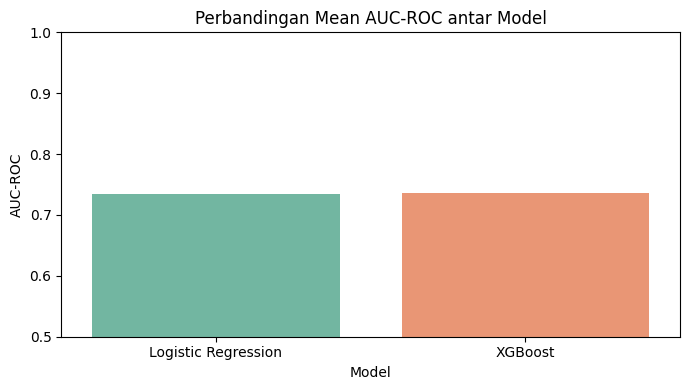

In [23]:
results = pd.DataFrame({
    'Model'       : ['Logistic Regression', 'XGBoost'],
    'Mean Acc'    : [np.mean(acc_lr),       np.mean(acc_xgb)],
    'Mean LogLoss': [np.mean(logloss_lr),   np.mean(logloss_xgb)],
    'Mean AUC'    : [np.mean(auc_lr),       np.mean(auc_xgb)]
})

print('=== PERBANDINGAN HASIL MODEL ===')
display(results)

plt.figure(figsize=(7, 4))
sns.barplot(data=results, x='Model', y='Mean AUC', palette='Set2')
plt.title('Perbandingan Mean AUC-ROC antar Model')
plt.ylim(0.5, 1.0)
plt.ylabel('AUC-ROC')
plt.tight_layout()
plt.show()

---
## 8. FEATURE IMPORTANCE

### 8.1 Feature Importance - XGBoost

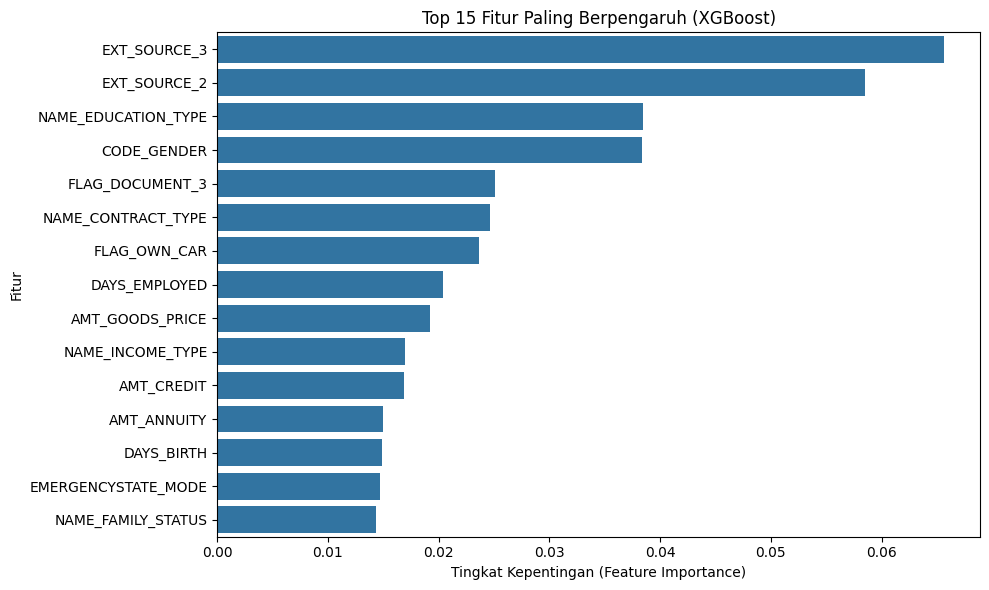

In [24]:
xgb_importances = xgb_model.feature_importances_

df_xgb_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False)

top_15_xgb = df_xgb_imp.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_15_xgb, x='Importance', y='Feature')
plt.title('Top 15 Fitur Paling Berpengaruh (XGBoost)')
plt.xlabel('Tingkat Kepentingan (Feature Importance)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

In [25]:
# Kamus penjelasan variabel Home Credit
feature_descriptions = {
    'EXT_SOURCE_1'               : 'Skor kredit eksternal dari sumber pihak ketiga (sumber 1). Makin tinggi skornya, makin AMAN profil pemohon.',
    'EXT_SOURCE_2'               : 'Skor kredit eksternal dari sumber pihak ketiga (sumber 2). Salah satu prediktor terkuat untuk membedakan pemohon AMAN vs BERISIKO.',
    'EXT_SOURCE_3'               : 'Skor kredit eksternal dari sumber pihak ketiga (sumber 3). Makin tinggi skornya, makin AMAN profil pemohon.',
    'DAYS_BIRTH'                 : 'Usia pemohon dalam tahun. Pemohon yang lebih tua cenderung lebih AMAN karena lebih berpengalaman secara finansial.',
    'DAYS_EMPLOYED'              : 'Lama pemohon bekerja di pekerjaan saat ini. Makin lama bekerja = stabilitas lebih tinggi = cenderung AMAN.',
    'DAYS_REGISTRATION'          : 'Berapa hari lalu pemohon mendaftarkan dokumen identitas. Pendaftaran sangat baru bisa jadi sinyal BERISIKO.',
    'DAYS_ID_PUBLISH'            : 'Berapa hari lalu pemohon memperbarui KTP. Dokumen sangat baru bisa menjadi sinyal BERISIKO.',
    'DAYS_LAST_PHONE_CHANGE'     : 'Berapa hari lalu pemohon ganti nomor telepon. Pergantian sangat baru bisa menandakan pemohon tidak stabil.',
    'AMT_CREDIT'                 : 'Total jumlah kredit yang diajukan. Kredit terlalu besar relatif pendapatan meningkatkan risiko menjadi BERISIKO.',
    'AMT_ANNUITY'                : 'Besarnya cicilan tahunan. Cicilan yang memberatkan relatif terhadap pendapatan membuat pemohon lebih BERISIKO.',
    'AMT_INCOME_TOTAL'           : 'Total pendapatan tahunan pemohon. Pendapatan lebih tinggi cenderung membuat pemohon lebih AMAN.',
    'AMT_GOODS_PRICE'            : 'Harga barang/aset yang dibiayai kredit. Berkaitan erat dengan besar kredit yang diajukan.',
    'REGION_POPULATION_RELATIVE' : 'Kepadatan penduduk relatif di wilayah tempat tinggal. Wilayah tertentu memiliki profil risiko yang berbeda-beda.',
    'HOUR_APPR_PROCESS_START'    : 'Jam pengajuan kredit dilakukan. Pengajuan di luar jam kerja normal kadang berkorelasi dengan profil tertentu.',
    'OWN_CAR_AGE'                : 'Usia kendaraan yang dimiliki pemohon. Kendaraan sangat tua bisa menggambarkan kondisi finansial yang terbatas.',
    'CNT_CHILDREN'               : 'Jumlah anak pemohon. Lebih banyak tanggungan berpotensi membuat pemohon lebih BERISIKO.',
    'CNT_FAM_MEMBERS'            : 'Jumlah total anggota keluarga. Mencerminkan beban tanggungan finansial pemohon.',
    'REGION_RATING_CLIENT'       : 'Rating risiko wilayah tempat tinggal pemohon. Rating tinggi = wilayah BERISIKO.',
    'REGION_RATING_CLIENT_W_CITY': 'Rating risiko wilayah + kota tempat tinggal. Versi lebih detail dari REGION_RATING_CLIENT.',
    'DAYS_EMPLOYED_ANOMALY'      : 'Flag: 1 jika pemohon tidak/belum bekerja. Pemohon tidak bekerja cenderung lebih BERISIKO.',
    'NAME_EDUCATION_TYPE'        : 'Tingkat pendidikan pemohon. Pendidikan lebih tinggi cenderung berasosiasi dengan profil lebih AMAN.',
    'NAME_INCOME_TYPE'           : 'Jenis sumber pendapatan (karyawan, wiraswasta, pensiunan, dll). Berpengaruh pada stabilitas pendapatan.',
    'CODE_GENDER'                : 'Jenis kelamin pemohon. Secara statistik terdapat perbedaan profil risiko antar gender.',
    'FLAG_OWN_CAR'               : 'Kepemilikan kendaraan (1=Ya, 0=Tidak). Memiliki aset berkorelasi dengan profil lebih AMAN.',
    'FLAG_OWN_REALTY'            : 'Kepemilikan properti/rumah (1=Ya, 0=Tidak). Memiliki properti berkorelasi kuat dengan profil AMAN.',
    'OCCUPATION_TYPE'            : 'Jenis pekerjaan pemohon. Berpengaruh pada stabilitas dan level penghasilan.',
    'ORGANIZATION_TYPE'          : 'Jenis perusahaan tempat pemohon bekerja. Sektor formal cenderung lebih stabil.',
    'NAME_CONTRACT_TYPE'         : 'Jenis kontrak kredit (Cash loans vs Revolving loans). Tipe berbeda memiliki profil risiko berbeda.',
    'NAME_FAMILY_STATUS'         : 'Status pernikahan pemohon. Berpengaruh pada profil risiko secara statistik.',
    'NAME_HOUSING_TYPE'          : 'Tipe hunian pemohon (rumah sendiri, sewa, dll). Mencerminkan stabilitas tempat tinggal dan kondisi finansial.',
}

print('=== PENJELASAN TOP 15 VARIABEL PALING BERPENGARUH (XGBoost) ===\n')
for rank, (_, row) in enumerate(top_15_xgb.iterrows(), 1):
    feat = row['Feature']
    desc = feature_descriptions.get(feat, 'Tidak ada deskripsi tersedia.')
    print(f"{rank:2}. {feat}")
    print(f"    Importance : {row['Importance']:.6f}")
    print(f"    Keterangan : {desc}")
    print()

=== PENJELASAN TOP 15 VARIABEL PALING BERPENGARUH (XGBoost) ===

 1. EXT_SOURCE_3
    Importance : 0.065607
    Keterangan : Skor kredit eksternal dari sumber pihak ketiga (sumber 3). Makin tinggi skornya, makin AMAN profil pemohon.

 2. EXT_SOURCE_2
    Importance : 0.058459
    Keterangan : Skor kredit eksternal dari sumber pihak ketiga (sumber 2). Salah satu prediktor terkuat untuk membedakan pemohon AMAN vs BERISIKO.

 3. NAME_EDUCATION_TYPE
    Importance : 0.038420
    Keterangan : Tingkat pendidikan pemohon. Pendidikan lebih tinggi cenderung berasosiasi dengan profil lebih AMAN.

 4. CODE_GENDER
    Importance : 0.038374
    Keterangan : Jenis kelamin pemohon. Secara statistik terdapat perbedaan profil risiko antar gender.

 5. FLAG_DOCUMENT_3
    Importance : 0.025127
    Keterangan : Tidak ada deskripsi tersedia.

 6. NAME_CONTRACT_TYPE
    Importance : 0.024665
    Keterangan : Jenis kontrak kredit (Cash loans vs Revolving loans). Tipe berbeda memiliki profil risiko berbeda.


### 8.2 Feature Importance - Logistic Regression

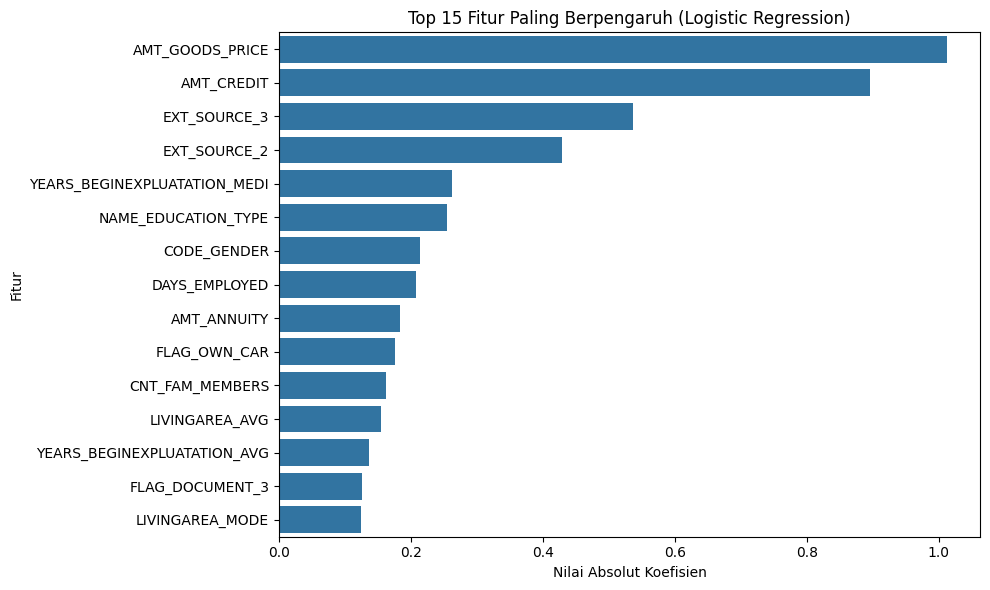

In [26]:
lr_importances = np.abs(logreg_model.coef_[0])

df_lr_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': lr_importances
}).sort_values(by='Importance', ascending=False)

top_15_lr = df_lr_imp.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_15_lr, x='Importance', y='Feature')
plt.title('Top 15 Fitur Paling Berpengaruh (Logistic Regression)')
plt.xlabel('Nilai Absolut Koefisien')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

In [27]:
print('=== PENJELASAN TOP 15 VARIABEL PALING BERPENGARUH (Logistic Regression) ===\n')
for rank, (_, row) in enumerate(top_15_lr.iterrows(), 1):
    feat = row['Feature']
    desc = feature_descriptions.get(feat, 'Tidak ada deskripsi tersedia.')
    print(f"{rank:2}. {feat}")
    print(f"    Koefisien Absolut : {row['Importance']:.6f}")
    print(f"    Keterangan        : {desc}")
    print()

=== PENJELASAN TOP 15 VARIABEL PALING BERPENGARUH (Logistic Regression) ===

 1. AMT_GOODS_PRICE
    Koefisien Absolut : 1.012055
    Keterangan        : Harga barang/aset yang dibiayai kredit. Berkaitan erat dengan besar kredit yang diajukan.

 2. AMT_CREDIT
    Koefisien Absolut : 0.895975
    Keterangan        : Total jumlah kredit yang diajukan. Kredit terlalu besar relatif pendapatan meningkatkan risiko menjadi BERISIKO.

 3. EXT_SOURCE_3
    Koefisien Absolut : 0.536775
    Keterangan        : Skor kredit eksternal dari sumber pihak ketiga (sumber 3). Makin tinggi skornya, makin AMAN profil pemohon.

 4. EXT_SOURCE_2
    Koefisien Absolut : 0.429072
    Keterangan        : Skor kredit eksternal dari sumber pihak ketiga (sumber 2). Salah satu prediktor terkuat untuk membedakan pemohon AMAN vs BERISIKO.

 5. YEARS_BEGINEXPLUATATION_MEDI
    Koefisien Absolut : 0.262084
    Keterangan        : Tidak ada deskripsi tersedia.

 6. NAME_EDUCATION_TYPE
    Koefisien Absolut : 0.255024
  

---
## 9. ROC CURVE PERBANDINGAN MODEL

> Visualisasi ROC Curve untuk melihat performa model pada validation fold terakhir.

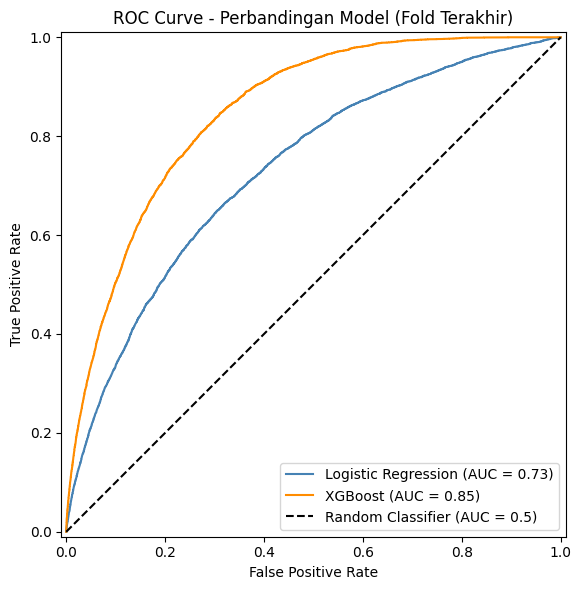

In [28]:
train_idx_last, val_idx_last = list(cv.split(X_scaled, y))[-1]

X_val_lr  = X_scaled[val_idx_last]
X_val_xgb = X_scaled_xgb[val_idx_last]
y_val_roc = y.iloc[val_idx_last]

y_prob_lr_roc  = logreg_model.predict_proba(X_val_lr)[:, 1]
y_prob_xgb_roc = xgb_model.predict_proba(X_val_xgb)[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_val_roc, y_prob_lr_roc,
                                  name='Logistic Regression', ax=ax, color='steelblue')
RocCurveDisplay.from_predictions(y_val_roc, y_prob_xgb_roc,
                                  name='XGBoost', ax=ax, color='darkorange')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
ax.set_title('ROC Curve - Perbandingan Model (Fold Terakhir)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 10. PERBANDINGAN DISTRIBUSI PREDIKSI TEST SET

> Membandingkan hasil prediksi probabilitas dari kedua model pada data test:
> berapa pemohon yang diprediksi **BERISIKO (prob > 0.5)** vs **AMAN (prob ≤ 0.5)**.

In [29]:
# ============================================================
# 10.1 Tabel Ringkasan: Jumlah Prediksi Berisiko vs Aman
# ============================================================
threshold = 0.5

pred_lr_binary  = (y_pred_lr_proba  >= threshold).astype(int)
pred_xgb_binary = (y_pred_xgb_proba >= threshold).astype(int)

total = len(df_test)

summary = pd.DataFrame({
    'Model'                          : ['Logistic Regression', 'XGBoost'],
    'Total Pemohon'                  : [total, total],
    'Prediksi AMAN (prob ≤ 0.5)'     : [(pred_lr_binary  == 0).sum(), (pred_xgb_binary == 0).sum()],
    'Prediksi BERISIKO (prob > 0.5)' : [(pred_lr_binary  == 1).sum(), (pred_xgb_binary == 1).sum()],
    '% Berisiko'                     : [
        f'{(pred_lr_binary  == 1).mean():.2%}',
        f'{(pred_xgb_binary == 1).mean():.2%}'
    ]
})

print('=== RINGKASAN PREDIKSI TEST SET (Threshold = 0.5) ===')
display(summary)

=== RINGKASAN PREDIKSI TEST SET (Threshold = 0.5) ===


,Model,Total Pemohon,Prediksi AMAN (prob ≤ 0.5),Prediksi BERISIKO (prob > 0.5),% Berisiko
0,Logistic Regression,48744,31941,16803,34.47%
1,XGBoost,48744,34625,14119,28.97%


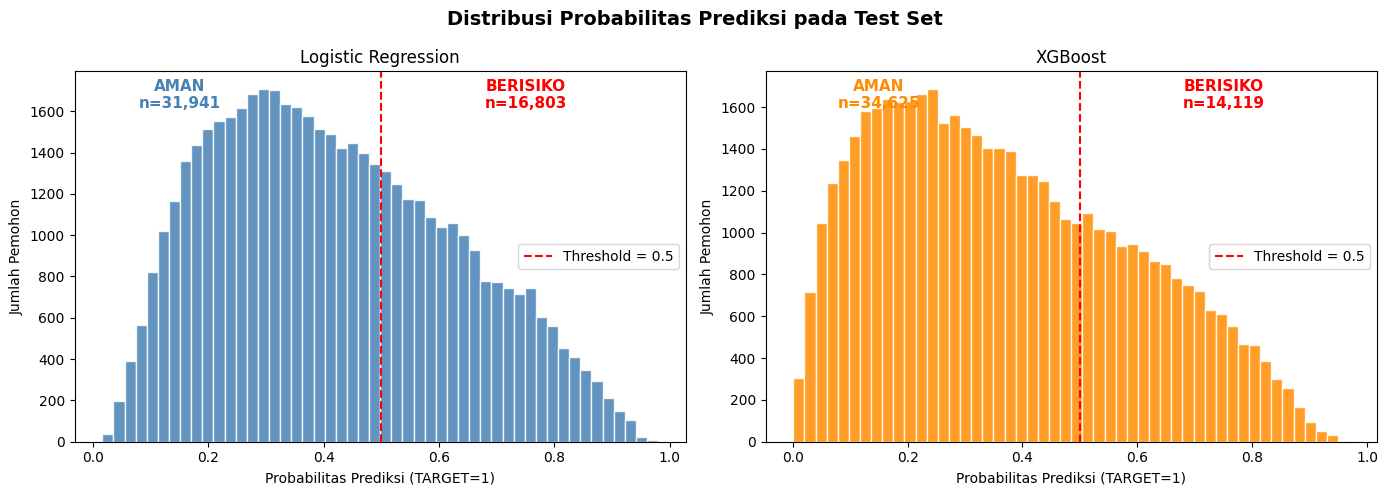

In [30]:
# ============================================================
# 10.2 Visualisasi: Distribusi Probabilitas Prediksi
# ============================================================
n_lr_aman      = (pred_lr_binary  == 0).sum()
n_lr_berisiko  = (pred_lr_binary  == 1).sum()
n_xgb_aman     = (pred_xgb_binary == 0).sum()
n_xgb_berisiko = (pred_xgb_binary == 1).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Probabilitas Prediksi pada Test Set', fontsize=14, fontweight='bold')

# --- Logistic Regression ---
axes[0].hist(y_pred_lr_proba, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(x=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold}')
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Probabilitas Prediksi (TARGET=1)')
axes[0].set_ylabel('Jumlah Pemohon')
axes[0].legend()
axes[0].text(0.15, axes[0].get_ylim()[1]*0.9, f'AMAN\nn={n_lr_aman:,}',
             ha='center', color='steelblue', fontsize=11, fontweight='bold')
axes[0].text(0.75, axes[0].get_ylim()[1]*0.9, f'BERISIKO\nn={n_lr_berisiko:,}',
             ha='center', color='red', fontsize=11, fontweight='bold')

# --- XGBoost ---
axes[1].hist(y_pred_xgb_proba, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(x=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold}')
axes[1].set_title('XGBoost')
axes[1].set_xlabel('Probabilitas Prediksi (TARGET=1)')
axes[1].set_ylabel('Jumlah Pemohon')
axes[1].legend()
axes[1].text(0.15, axes[1].get_ylim()[1]*0.9, f'AMAN\nn={n_xgb_aman:,}',
             ha='center', color='darkorange', fontsize=11, fontweight='bold')
axes[1].text(0.75, axes[1].get_ylim()[1]*0.9, f'BERISIKO\nn={n_xgb_berisiko:,}',
             ha='center', color='red', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

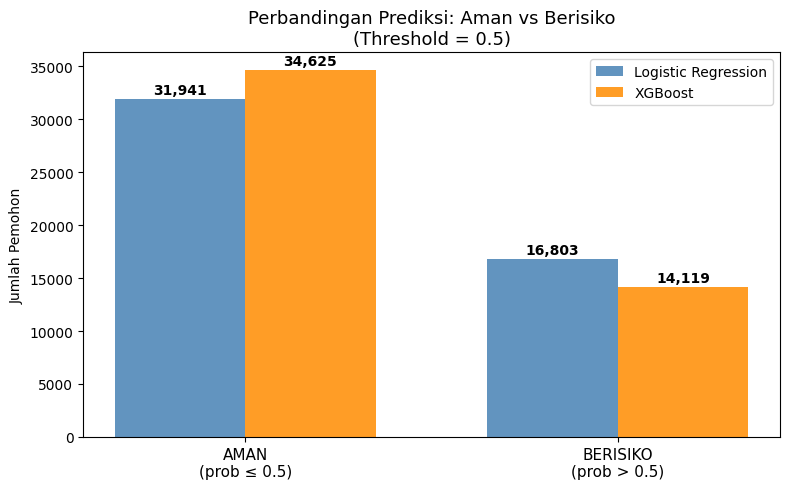


=== KESIMPULAN ===
Logistic Regression → Berisiko: 16,803 (34.47%) | Aman: 31,941 (65.53%)
XGBoost             → Berisiko: 14,119 (28.97%) | Aman: 34,625 (71.03%)


In [31]:
# ============================================================
# 10.3 Visualisasi: Bar Chart Perbandingan Langsung
# ============================================================
categories = ['AMAN\n(prob ≤ 0.5)', 'BERISIKO\n(prob > 0.5)']
lr_counts  = [n_lr_aman,  n_lr_berisiko]
xgb_counts = [n_xgb_aman, n_xgb_berisiko]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_lr  = ax.bar(x - width/2, lr_counts,  width, label='Logistic Regression', color='steelblue',  alpha=0.85)
bars_xgb = ax.bar(x + width/2, xgb_counts, width, label='XGBoost',             color='darkorange', alpha=0.85)

for bar in bars_lr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars_xgb:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Perbandingan Prediksi: Aman vs Berisiko\n(Threshold = 0.5)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Jumlah Pemohon')
ax.legend()
plt.tight_layout()
plt.show()

print('\n=== KESIMPULAN ===')
print(f'Logistic Regression → Berisiko: {n_lr_berisiko:,} ({n_lr_berisiko/total:.2%}) | Aman: {n_lr_aman:,} ({n_lr_aman/total:.2%})')
print(f'XGBoost             → Berisiko: {n_xgb_berisiko:,} ({n_xgb_berisiko/total:.2%}) | Aman: {n_xgb_aman:,} ({n_xgb_aman/total:.2%})')

In [32]:
import pandas as pd

# Melakukan prediksi probabilitas menggunakan model XGBoost yang sudah dilatih
# X_test_scaled_xgb adalah data test yang sudah dipreprocessing dan di-scaling
y_pred_xgb_proba = xgb_model.predict_proba(X_test_scaled_xgb)[:, 1]

# Membuat DataFrame hasil prediksi sesuai format submission
submission_xgb = pd.DataFrame({
    'SK_ID_CURR': df_test['SK_ID_CURR'],
    'TARGET'    : y_pred_xgb_proba
})

# Menyimpan hasil ke dalam file CSV
submission_xgb.to_csv('/kaggle/working/submission_xgb.csv', index=False)

print('File submission_xgb.csv berhasil disimpan.')

File submission_xgb.csv berhasil disimpan.
